In [14]:
%reset -f

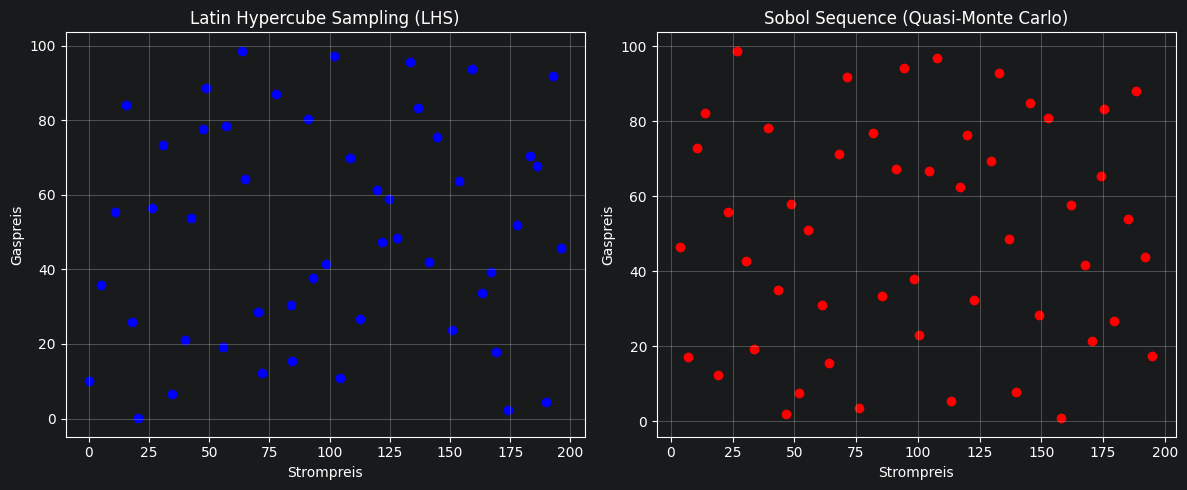

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

# ----------------------------
# Settings
# ----------------------------
n_samples = 50
d = 2  # Strom- und Gaspreis

# ----------------------------
# 1. Latin Hypercube Sampling
# ----------------------------
lhs_sampler = qmc.LatinHypercube(d=d)
lhs_sample = lhs_sampler.random(n=n_samples)

# optional: Skaliere auf realistische Preisbereiche
# z.B. Strom: [0, 200], Gas: [0, 100]
lower_bounds = np.array([0, 0])
upper_bounds = np.array([200, 100])

lhs_scaled = qmc.scale(lhs_sample, lower_bounds, upper_bounds)

# ----------------------------
# 2. Sobol Sampling
# ----------------------------
sobol_sampler = qmc.Sobol(d=d, scramble=True)
sobol_sample = sobol_sampler.random(n_samples)

sobol_scaled = qmc.scale(sobol_sample, lower_bounds, upper_bounds)

# ----------------------------
# 3. Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(lhs_scaled[:, 0], lhs_scaled[:, 1], c='blue')
axes[0].set_title("Latin Hypercube Sampling (LHS)")
axes[0].set_xlabel("Strompreis")
axes[0].set_ylabel("Gaspreis")
axes[0].grid(True)

axes[1].scatter(sobol_scaled[:, 0], sobol_scaled[:, 1], c='red')
axes[1].set_title("Sobol Sequence (Quasi-Monte Carlo)")
axes[1].set_xlabel("Strompreis")
axes[1].set_ylabel("Gaspreis")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [22]:
c_el_range = [0, 200]  # Strompreisbereich

C:\Users\erdem\Documents\Studium\ModE\modE\lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


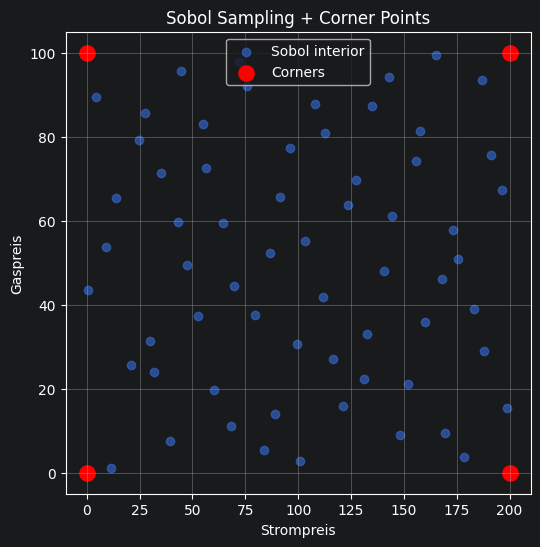

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

# ----------------------------
# Settings
# ----------------------------
n_samples = 63

lower_bounds = np.array([0, 0])
upper_bounds = np.array([200, 100])

# ----------------------------
# Sobol Interior Sampling
# ----------------------------
sobol = qmc.Sobol(d=2, scramble=True)

# optional: skip first point (Sobol starts at 0-vector often)
sobol_sample = sobol.random(n_samples)

sobol_scaled = qmc.scale(sobol_sample, lower_bounds, upper_bounds)

# ----------------------------
# Corner points (boundary guarantee)
# ----------------------------
corners = np.array([
    [lower_bounds[0], lower_bounds[1]],
    [lower_bounds[0], upper_bounds[1]],
    [upper_bounds[0], lower_bounds[1]],
    [upper_bounds[0], upper_bounds[1]],
])

# ----------------------------
# Combine
# ----------------------------
X = np.vstack([sobol_scaled, corners])

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6,6))

plt.scatter(sobol_scaled[:,0], sobol_scaled[:,1], alpha=0.6, label="Sobol interior")
plt.scatter(corners[:,0], corners[:,1], color="red", s=120, label="Corners")

plt.xlabel("Strompreis")
plt.ylabel("Gaspreis")
plt.title("Sobol Sampling + Corner Points")
plt.grid(True)
plt.legend()
plt.show()

Training set composition: 40 points per method
  4 corners  +  4 edge midpoints  +  32 interior

Quality metrics (interior + boundary combined):
  Sobol   discrepancy = 0.00192   min pairwise dist = 21.29 €/MWh
  LHS     discrepancy = 0.00208   min pairwise dist = 30.87 €/MWh

Comparison plot saved.
CSVs saved:  training_samples_sobol.csv  |  training_samples_lhs.csv


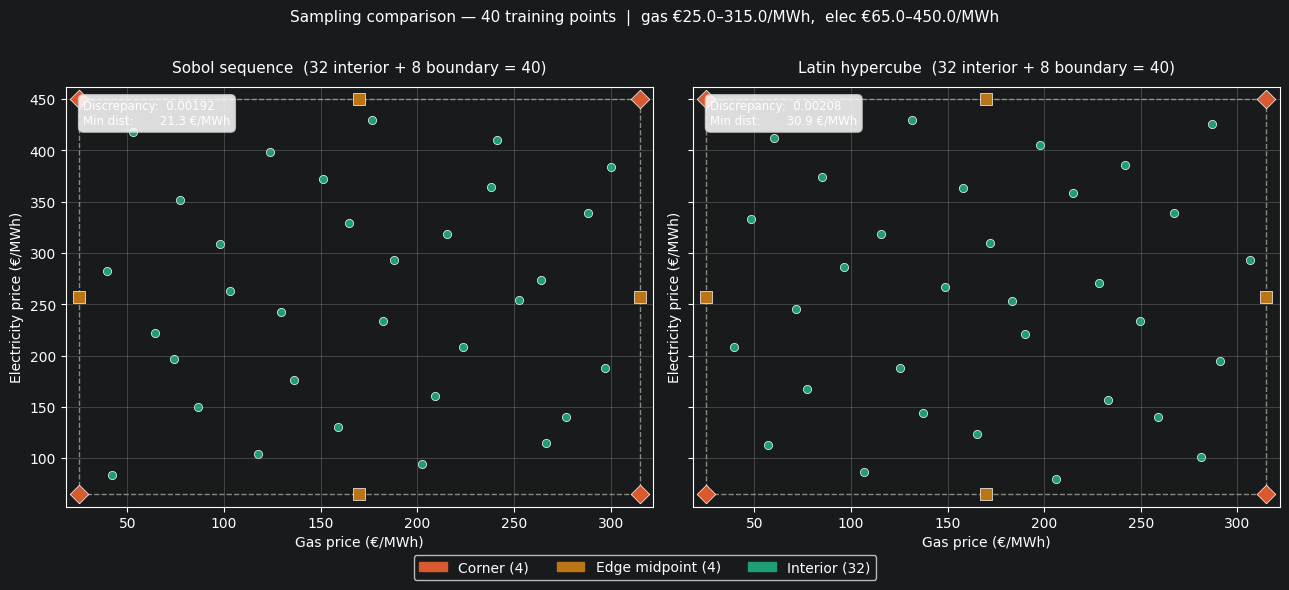

In [44]:
"""
Sampling script for OPEX surrogate model training set.

Generates 40 points per method:
  - Sobol:  32 interior (power-of-2) + 4 corners + 4 edge midpoints
  - LHS:    32 interior (any n works) + 4 corners + 4 edge midpoints

Outputs
-------
  training_samples_sobol.csv
  training_samples_lhs.csv
  sampling_comparison.png   — side-by-side scatter + quality metrics
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import qmc

# ── Price ranges ─────────────────────────────────────────────────────────────
GAS_MIN,  GAS_MAX  = 25.0, 315.0   # €/MWh
ELEC_MIN, ELEC_MAX = 65.0, 450.0   # €/MWh


# -- Number of sample points -----------------------------
N_INTERIOR = 32   # interior points per method
              #   Sobol: must be power of 2  →  maximum 32 point with 40 points available
              #   LHS:   no restriction      →  32 chosen to keep sets comparable
N_CORNERS  = 4
N_EDGES    = 4
N_TOTAL    = N_INTERIOR + N_CORNERS + N_EDGES   # = 40

MARGIN = 0.025   # 2.5 % inset in [0,1]-space so interior pts stay clear of boundary

# ── Shared boundary points (identical for both methods) ───────────────────────
corners = np.array([
    [GAS_MIN,  ELEC_MIN],   # bottom-left
    [GAS_MAX,  ELEC_MIN],   # bottom-right
    [GAS_MIN,  ELEC_MAX],   # top-left
    [GAS_MAX,  ELEC_MAX],   # top-right
])

gas_mid  = (GAS_MIN  + GAS_MAX)  / 2
elec_mid = (ELEC_MIN + ELEC_MAX) / 2

edge_midpoints = np.array([
    [gas_mid,  ELEC_MIN],   # bottom edge centre
    [gas_mid,  ELEC_MAX],   # top edge centre
    [GAS_MIN,  elec_mid],   # left edge centre
    [GAS_MAX,  elec_mid],   # right edge centre
])

boundary_pts = np.vstack([corners, edge_midpoints])

# ── Helper: apply margin inset then scale to price domain ────────────────────
def to_price_domain(raw_unit):
    """raw_unit: array in [0,1]^2  →  scaled with margin, in price units."""
    inset = MARGIN + raw_unit * (1 - 2 * MARGIN)
    return qmc.scale(inset,
                     l_bounds=[GAS_MIN,  ELEC_MIN],
                     u_bounds=[GAS_MAX,  ELEC_MAX])

# ── Helper: assemble DataFrame ────────────────────────────────────────────────
def make_df(interior_pts):
    labels = (["corner"] * N_CORNERS +
              ["edge_midpoint"] * N_EDGES +
              ["interior"] * N_INTERIOR)
    pts = np.vstack([boundary_pts, interior_pts])
    return pd.DataFrame({
        "gas_price":         pts[:, 0],
        "electricity_price": pts[:, 1],
        "point_type":        labels,
    }), pts

# ── Helper: quality metrics ───────────────────────────────────────────────────
def quality(pts):
    """Returns discrepancy and minimum pairwise distance."""
    unit = qmc.scale(pts,
                     l_bounds=[GAS_MIN,  ELEC_MIN],
                     u_bounds=[GAS_MAX,  ELEC_MAX],
                     reverse=True)
    disc = qmc.discrepancy(unit)
    n = len(pts)
    dists = [np.linalg.norm(pts[i] - pts[j])
             for i in range(n) for j in range(i + 1, n)]
    return disc, min(dists)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. SOBOL
# ═══════════════════════════════════════════════════════════════════════════════
sobol_sampler = qmc.Sobol(d=2, scramble=True, seed=42)
sobol_raw     = sobol_sampler.random(N_INTERIOR)          # [0,1]², power-of-2 n
sobol_interior = to_price_domain(sobol_raw)

df_sobol, sobol_all = make_df(sobol_interior)
sobol_disc, sobol_min_dist = quality(sobol_all)

# ═══════════════════════════════════════════════════════════════════════════════
# 2. LHS  (optimized with random column-descent to improve pairing quality)
# ═══════════════════════════════════════════════════════════════════════════════
# No power-of-2 requirement — n=32 chosen purely to match Sobol for comparison.
# optimization="random-cd" runs column swaps to minimise L2 discrepancy.
lhs_sampler  = qmc.LatinHypercube(d=2, scramble=True,
                                   optimization="random-cd", seed=42)
lhs_raw      = lhs_sampler.random(N_INTERIOR)             # [0,1]², any n works
lhs_interior = to_price_domain(lhs_raw)

df_lhs, lhs_all = make_df(lhs_interior)
lhs_disc, lhs_min_dist = quality(lhs_all)

# ── Print summary ─────────────────────────────────────────────────────────────
def print_summary(name, disc, min_dist):
    print(f"  {name:<6}  discrepancy = {disc:.5f}   min pairwise dist = {min_dist:.2f} €/MWh")

print(f"Training set composition: {N_TOTAL} points per method")
print(f"  {N_CORNERS} corners  +  {N_EDGES} edge midpoints  +  {N_INTERIOR} interior\n")
print("Quality metrics (interior + boundary combined):")
print_summary("Sobol", sobol_disc, sobol_min_dist)
print_summary("LHS",   lhs_disc,   lhs_min_dist)

# ═══════════════════════════════════════════════════════════════════════════════
# 3. COMPARISON PLOT
# ═══════════════════════════════════════════════════════════════════════════════
COLORS  = {"corner": "#D85A30", "edge_midpoint": "#BA7517", "interior": "#1D9E75"}
MARKERS = {"corner": "D",       "edge_midpoint": "s",       "interior": "o"}
SIZES   = {"corner": 90,        "edge_midpoint": 65,        "interior": 35}

def draw_boundary(ax):
    rect = mpatches.FancyBboxPatch(
        (GAS_MIN, ELEC_MIN),
        GAS_MAX - GAS_MIN, ELEC_MAX - ELEC_MIN,
        boxstyle="square,pad=0", linewidth=1,
        edgecolor="#888780", facecolor="none", linestyle="--",
    )
    ax.add_patch(rect)

def scatter_panel(ax, df, title, disc, min_dist):
    draw_boundary(ax)
    for ptype in ["interior", "edge_midpoint", "corner"]:
        mask = df["point_type"] == ptype
        ax.scatter(
            df.loc[mask, "gas_price"],
            df.loc[mask, "electricity_price"],
            c=COLORS[ptype], marker=MARKERS[ptype], s=SIZES[ptype],
            edgecolors="white", linewidths=0.5,
            zorder={"corner": 3, "edge_midpoint": 2, "interior": 1}[ptype],
        )
    ax.set_xlim(GAS_MIN - 7, GAS_MAX + 7)
    ax.set_ylim(ELEC_MIN - 12, ELEC_MAX + 12)
    ax.set_xlabel("Gas price (€/MWh)", fontsize=10)
    ax.set_ylabel("Electricity price (€/MWh)", fontsize=10)
    ax.set_title(title, fontsize=11, pad=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    # Metric annotation box
    info = (f"Discrepancy:  {disc:.5f}\n"
            f"Min dist:       {min_dist:.1f} €/MWh")
    ax.text(0.03, 0.97, info,
            transform=ax.transAxes, fontsize=8.5,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#cccccc", alpha=0.85))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

scatter_panel(axes[0], df_sobol,
              f"Sobol sequence  (32 interior + 8 boundary = 40)",
              sobol_disc, sobol_min_dist)
scatter_panel(axes[1], df_lhs,
              f"Latin hypercube  (32 interior + 8 boundary = 40)",
              lhs_disc, lhs_min_dist)

# Shared legend
legend_handles = [
    mpatches.Patch(color=COLORS["corner"],        label=f"Corner ({N_CORNERS})"),
    mpatches.Patch(color=COLORS["edge_midpoint"], label=f"Edge midpoint ({N_EDGES})"),
    mpatches.Patch(color=COLORS["interior"],      label=f"Interior ({N_INTERIOR})"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle(f"Sampling comparison — {N_TOTAL} training points  |  "
             f"gas €{GAS_MIN}–{GAS_MAX}/MWh,  elec €{ELEC_MIN}–{ELEC_MAX}/MWh",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("sampling_comparison.png", dpi=300, bbox_inches="tight")
# plt.close()
print("\nComparison plot saved.")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. EXPORT CSVs
# ═══════════════════════════════════════════════════════════════════════════════
df_sobol.to_csv("training_samples_sobol.csv", index=False, float_format="%.4f")
df_lhs.to_csv("training_samples_lhs.csv", index=False, float_format="%.4f")
print("CSVs saved:  training_samples_sobol.csv  |  training_samples_lhs.csv")